# Reproducing Figure 3 — Categorical target representations

Direct reproduction of Figure 3 in Klein et al. (2026), *Plasticity Loss in Deep
Reinforcement Learning: A Survey* (figure originally from Farebrother et al., 2024).

Three ways to turn a value-regression target into a categorical target over a fixed
support of atoms $z_1,\dots,z_5$, matching the paper's two-tier layout: the target
representation on top, the resulting probability bars $p_1,\dots,p_5$ below.

- **Two-hot** (Schrittwieser et al., 2020): mass on the two atoms bracketing a scalar target.
- **HL-Gauss** (Imani & White, 2018): a fixed-width Gaussian integrated over each bin.
- **C51** (Bellemare et al., 2017): a return distribution propagated through the Bellman
  map $r+\gamma Z$ and projected back onto the support.

Each mapping is deterministic and defined by a published formula: no data, no training,
no random seed. Running this notebook writes `../figures/fig3_categorical_losses.png`
and `../results/categorical_masses.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

CWD = os.getcwd()
ROOT = os.path.dirname(CWD) if os.path.basename(CWD) == "code" else CWD
FIG = os.path.join(ROOT, "figures"); RES = os.path.join(ROOT, "results")
os.makedirs(FIG, exist_ok=True); os.makedirs(RES, exist_ok=True)
NAVY, RED, GREY = "#12233f", "#b8443a", "#9aa0a6" 

## Support and parameters

Five atoms, matching the paper's schematic. The original states no numeric values;
these are documented choices.

In [2]:
V_MIN, V_MAX, N_ATOMS = -1.0, 1.0, 5
atoms = np.linspace(V_MIN, V_MAX, N_ATOMS)      # [-1, -0.5, 0, 0.5, 1]
dz = atoms[1] - atoms[0]                         # 0.5
edges = np.concatenate(([atoms[0] - dz / 2],
                        (atoms[:-1] + atoms[1:]) / 2,
                        [atoms[-1] + dz / 2]))
pos = np.arange(N_ATOMS)                          # plotting positions 0..4
def to_pos(v):                                    # value -> plotting position
    return (np.asarray(v) - V_MIN) / dz

Y_TWOHOT = -0.20       # two-hot target, between z2 and z3
Y_HLGAUSS = 0.00       # HL-Gauss centred on the middle atom z3
SIGMA = 0.9 * dz       # HL-Gauss Gaussian width
C51_REWARD = 0.10      # r in the Bellman map r + gamma*Z
C51_GAMMA = 0.80       # gamma

## The three mappings, each from its defining equation

In [3]:
def two_hot(y, atoms):
    """Linear-interpolation two-hot encoding of scalar y onto `atoms`."""
    m = np.zeros_like(atoms)
    y = np.clip(y, atoms[0], atoms[-1])
    u = np.searchsorted(atoms, y)
    if atoms[u] == y:
        m[u] = 1.0
        return m
    lo = u - 1
    frac = (y - atoms[lo]) / (atoms[u] - atoms[lo])
    m[lo] = 1.0 - frac
    m[u] = frac
    return m


def hl_gauss(y, edges, sigma):
    """HL-Gauss: integrate N(y, sigma^2) over each bin defined by `edges`."""
    cdf = norm.cdf(edges, loc=y, scale=sigma)
    m = np.diff(cdf)
    return m / m.sum()


def c51_project(src_probs, atoms, r, gamma, v_min, v_max):
    """Categorical (C51) projection of the Bellman target r + gamma*atoms."""
    dz = atoms[1] - atoms[0]
    m = np.zeros_like(atoms)
    for p, z in zip(src_probs, atoms):
        Tz = np.clip(r + gamma * z, v_min, v_max)
        b = np.clip((Tz - v_min) / dz, 0.0, len(atoms) - 1)
        lo, up = int(np.floor(b)), int(np.ceil(b))
        if lo == up:
            m[lo] += p
        else:
            m[lo] += p * (up - b)
            m[up] += p * (b - lo)
    return m

In [4]:
p_twohot = two_hot(Y_TWOHOT, atoms)
p_hlgauss = hl_gauss(Y_HLGAUSS, edges, SIGMA)

# source return distribution Z for the C51 panel (peaked at the centre)
src = np.array([0.08, 0.22, 0.40, 0.22, 0.08]); src = src / src.sum()
Tz = C51_REWARD + C51_GAMMA * atoms          # Bellman image r + gamma*Z
p_c51 = c51_project(src, atoms, C51_REWARD, C51_GAMMA, V_MIN, V_MAX)

for name, p in [("two-hot", p_twohot), ("HL-Gauss", p_hlgauss), ("C51", p_c51)]:
    assert abs(p.sum() - 1.0) < 1e-9, f"{name} mass sums to {p.sum()}"
print("all three distributions sum to 1")

all three distributions sum to 1


## Save the per-bin mass table

In [5]:
masses = pd.DataFrame({
    "atom": np.round(atoms, 4),
    "two_hot": np.round(p_twohot, 4),
    "hl_gauss": np.round(p_hlgauss, 4),
    "c51_source": np.round(src, 4),
    "c51_projected": np.round(p_c51, 4),
})
masses.to_csv(os.path.join(RES, "categorical_masses.csv"), index=False)
masses

,atom,two_hot,hl_gauss,c51_source,c51_projected
0,-1.0,0.0,0.0453,0.08,0.032
1,-0.5,0.4,0.2428,0.22,0.180
2,0.0,0.6,0.4238,0.40,0.408
3,0.5,0.0,0.2428,0.22,0.316
4,1.0,0.0,0.0453,0.08,0.064


## Figure 3 Reproduction

Each panel shows the target representation in the upper band and the resulting
probability bars $p_1..p_5$ in the lower band, with arrows from the representation
down onto the atoms.

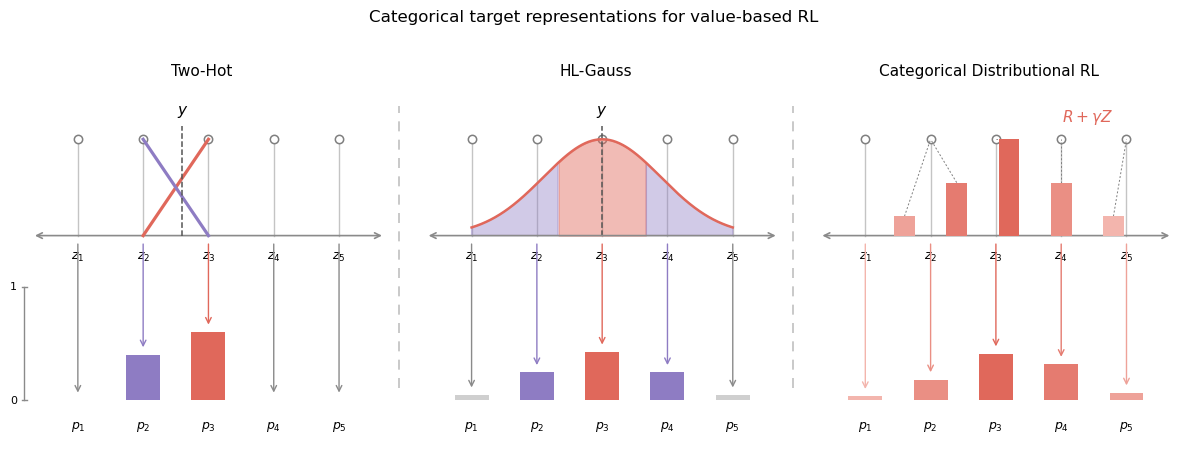

In [6]:
PURPLE, RED, PINK = "#8E7CC3", "#E0685B", "#F3B5AD"
AX, STEM, EDGE, GREYBAR = "#8a8a8a", "#c4c4c4", "#7f7f7f", "#cfcfcf"
pos = np.arange(N_ATOMS)
def to_pos(v): return (np.asarray(v, float) - V_MIN) / dz
TB, TH, BAR_W = 1.45, 0.85, 0.52          # top-band base, height, bar width

def blend(c_hi, c_lo, t):
    a = np.array(mcolors.to_rgb(c_hi)); b = np.array(mcolors.to_rgb(c_lo))
    return tuple(a * (1 - t) + b * t)

def scaffold(a, title, show_scale=False):
    """Value axis, atom stems + open circles, z/p labels, optional 0/1 scale."""
    a.annotate("", xy=(4.7, TB), xytext=(-0.7, TB),
               arrowprops=dict(arrowstyle="<->", color=AX, lw=1.2))
    for i in pos:
        a.plot([i, i], [TB, TB + TH], color=STEM, lw=1.0, zorder=1)
        a.plot(i, TB + TH, marker="o", mfc="white", mec=EDGE, ms=6, mew=1.1, zorder=2)
        a.text(i, TB - 0.13, f"$z_{{{i+1}}}$", ha="center", va="top", fontsize=9)
        a.text(i, -0.17, f"$p_{{{i+1}}}$", ha="center", va="top", fontsize=9)
    if show_scale:
        a.plot([-0.82, -0.82], [0, 1], color=AX, lw=1.0)
        for yy in (0, 1):
            a.plot([-0.86, -0.78], [yy, yy], color=AX, lw=1.0)
            a.text(-0.93, yy, str(yy), ha="right", va="center", fontsize=8)
    a.set_title(title, fontsize=11, pad=12)
    a.set_xlim(-1.0, 4.8); a.set_ylim(-0.38, 2.72); a.axis("off")

def drops(a, bars, colors):
    """Colour-matched projection arrows from each atom down to its bar."""
    for i in pos:
        a.annotate("", xy=(i, max(bars[i], 0.0) + 0.04), xytext=(i, TB - 0.05),
                   arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.0))

fig, ax = plt.subplots(1, 3, figsize=(12, 4.4))

# ---------- Two-Hot ----------
a = ax[0]
yp = to_pos(Y_TWOHOT); lo = int(np.floor(yp)); up = lo + 1
cols = [AX] * N_ATOMS; cols[lo] = PURPLE; cols[up] = RED
scaffold(a, "Two-Hot", show_scale=True)
a.plot([lo, up], [TB, TB + TH], color=RED, lw=2.3, zorder=3)        # rising -> z_up (red)
a.plot([lo, up], [TB + TH, TB], color=PURPLE, lw=2.3, zorder=3)     # falling -> z_lo (purple)
a.plot([yp, yp], [TB, TB + TH + 0.12], color="#555", lw=1.1, ls="--", zorder=4)
a.text(yp, TB + TH + 0.22, "$y$", ha="center", fontsize=11)
barcols = [GREYBAR] * N_ATOMS; barcols[lo] = PURPLE; barcols[up] = RED
a.bar(pos, p_twohot, width=BAR_W, color=barcols, zorder=3)
drops(a, p_twohot, cols)

# ---------- HL-Gauss ----------
a = ax[1]
m = int(np.argmax(p_hlgauss))
barcols = [GREYBAR] * N_ATOMS
for i in pos:
    if i == m: barcols[i] = RED
    elif abs(i - m) == 1: barcols[i] = PURPLE
dropcols = [c if c != GREYBAR else AX for c in barcols]
scaffold(a, "HL-Gauss")
xs = np.linspace(V_MIN, V_MAX, 400); xp = to_pos(xs)
g = norm.pdf(xs, Y_HLGAUSS, SIGMA); g = TB + (g / g.max()) * TH
core = np.abs(xs - Y_HLGAUSS) <= 0.75 * SIGMA
a.fill_between(xp, TB, g, where=core, color=RED, alpha=0.45, zorder=2)
a.fill_between(xp, TB, g, where=~core, color=PURPLE, alpha=0.40, zorder=2)
a.plot(xp, g, color=RED, lw=1.8, zorder=3)
a.plot([to_pos(Y_HLGAUSS)] * 2, [TB, TB + TH + 0.12], color="#555", lw=1.1, ls="--")
a.text(to_pos(Y_HLGAUSS), TB + TH + 0.22, "$y$", ha="center", fontsize=11)
a.bar(pos, p_hlgauss, width=BAR_W, color=barcols, zorder=3)
drops(a, p_hlgauss, dropcols)

# ---------- C51 ----------
a = ax[2]
cord = np.argsort(-p_c51); crank = {j: r for r, j in enumerate(cord)}
barcols = [blend(RED, PINK, crank[i] / (N_ATOMS - 1)) for i in pos]
scaffold(a, "Categorical Distributional RL")
Tzp = to_pos(np.clip(Tz, V_MIN, V_MAX))
h = TB + (src / src.max()) * TH
sord = np.argsort(-src); srank = {j: r for r, j in enumerate(sord)}
for j in range(N_ATOMS):                              # R + gamma*Z as gradient bars
    c = blend(RED, PINK, srank[j] / (N_ATOMS - 1))
    a.bar(Tzp[j], h[j] - TB, width=0.32, bottom=TB, color=c, zorder=3)
    tgt = int(np.clip(round(Tzp[j]), 0, N_ATOMS - 1))   # dashed link to nearest atom
    a.plot([Tzp[j], tgt], [h[j], TB + TH], color=EDGE, lw=0.7, ls=(0, (2, 2)), zorder=2)
a.text(3.4, TB + TH + 0.16, r"$R+\gamma Z$", color=RED, ha="center", fontsize=11)
a.bar(pos, p_c51, width=BAR_W, color=barcols, zorder=3)
drops(a, p_c51, barcols)

# ---------- dashed panel dividers (as in the paper) ----------
fig.suptitle("Categorical target representations for value-based RL", y=1.02, fontsize=12)
fig.tight_layout()
fig.canvas.draw()
for i in range(2):
    xm = (ax[i].get_position().x1 + ax[i + 1].get_position().x0) / 2
    fig.add_artist(mlines.Line2D([xm, xm], [0.16, 0.80], transform=fig.transFigure,
                                 color="#c0c0c0", lw=1.2, ls=(0, (6, 5))))
fig.savefig(os.path.join(FIG, "fig3_categorical_losses.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary statistics

In [7]:
def nonzero(p, tol=1e-6): return int((p > tol).sum())
def entropy(p): q = p[p > 0]; return float(-(q * np.log(q)).sum())

print(f"support: {N_ATOMS} atoms on [{V_MIN}, {V_MAX}], dz={dz:.3f}")
print(f"two-hot y={Y_TWOHOT}, HL-Gauss centre={Y_HLGAUSS}, sigma={SIGMA:.3f} ({SIGMA/dz:.1f} bin), "
      f"C51 r={C51_REWARD}, gamma={C51_GAMMA}")
print(f"two-hot mass: {np.round(p_twohot,3).tolist()}")
print(f"hl_gauss mass: {np.round(p_hlgauss,3).tolist()}")
print(f"c51 projected: {np.round(p_c51,3).tolist()}")
print(f"nonzero bins  two-hot={nonzero(p_twohot)}  hl_gauss={nonzero(p_hlgauss)}  c51={nonzero(p_c51)}")
print(f"entropy(nats) two-hot={entropy(p_twohot):.3f}  hl_gauss={entropy(p_hlgauss):.3f}  c51={entropy(p_c51):.3f}")

support: 5 atoms on [-1.0, 1.0], dz=0.500
two-hot y=-0.2, HL-Gauss centre=0.0, sigma=0.450 (0.9 bin), C51 r=0.1, gamma=0.8
two-hot mass: [0.0, 0.4, 0.6, 0.0, 0.0]
hl_gauss mass: [0.045, 0.243, 0.424, 0.243, 0.045]
c51 projected: [0.032, 0.18, 0.408, 0.316, 0.064]
nonzero bins  two-hot=2  hl_gauss=5  c51=5
entropy(nats) two-hot=0.673  hl_gauss=1.332  c51=1.325
